# Is the re-rendered izc sample the same population as OpenUniverse?

The generator no longer draws a contaminant from a luminosity function. It takes a **real
OpenUniverse object**, keeps everything the release records about it — template, shape, colour,
host screen — measures its brightness off its own light curve in the release's hdf5, and re-renders
it at a redshift the survey has no object at. So there is exactly one thing to be convinced of, and
it splits in two:

1. **Does the render reproduce the object it came from?** Put the object back where OpenUniverse
   already has it and compare against OpenUniverse's own photometry of it. If the template
   identification, the phase convention, the cosmology or the band integration is wrong, it shows
   up here and nowhere else can hide it.
2. **Does the move in redshift hold?** Objects of one template at many redshifts, put back in the
   rest frame. Their bands sample different parts of one SED, so they have to trace **one** curve —
   and the generator's model, swept through redshift, has to lie on it.

Three cells, in that order, then the population version of the first so the random draws below are
not cherry-picking. **Every object is drawn at random: change `seed` in any cell and look again.**

These cells read light curves from the release's hdf5, which the catalogue does not carry. The
setup cell below uses whichever healpix are actually readable on this machine — the Dropbox copy
holds placeholders that read as EMPTY instead of raising, so a healpix only counts if its file has
bytes in it.

In [1]:
import warnings
from functools import cache
from pathlib import Path

import h5py
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from kilonova.config import load_paths
from kilonova.photometry.roman_noise import roman_bandpasses
from kilonova.simulation import intermediate_z_contaminants as izc
from kilonova.simulation import openuniverse_parents

warnings.filterwarnings("ignore", category=UserWarning)

izc.register_sources()

BANDPASSES = roman_bandpasses()
ROMAN_BANDS = list(izc.ALL_ROMAN_BANDS)
BAND_COLOUR = dict(zip(ROMAN_BANDS, plt.cm.rainbow(np.linspace(0.0, 0.95, len(ROMAN_BANDS)))))
CLASS_LABELS = list(izc.CLASS_FRACTION)

# The light curves, which the catalogue does not carry: one 16 GB hdf5 per healpix. Both the
# Dropbox copy and the external volume hold files that READ AS EMPTY instead of raising when they
# are placeholders, so a healpix counts as usable only if some copy of it has bytes in it.
HDF5_DIRECTORIES = (
    Path("../data/openuniverse"),
    Path("/Volumes/T7/openuniverse2025"),
    Path(load_paths().openuniverse_source or "."),
)


def bandpass_wavelength_angstrom(band):
    """(wavelength in A, throughput) of one Roman band. galsim keeps its bandpasses in nm."""
    bandpass = BANDPASSES[band]
    wavelength_nm = np.asarray(bandpass.wave_list, dtype=float)
    throughput = np.asarray([bandpass(one) for one in wavelength_nm], dtype=float)
    return wavelength_nm * 10.0, throughput


def pivot_wavelength_angstrom(band):
    """Photon-weighted pivot wavelength, the one number that says where a band sits."""
    wavelength, throughput = bandpass_wavelength_angstrom(band)
    numerator = np.trapezoid(throughput * wavelength, wavelength)
    denominator = np.trapezoid(throughput / wavelength, wavelength)
    return float(np.sqrt(numerator / denominator))


@cache
def healpix_path(healpix):
    """The readable snana_{healpix}.hdf5, or None if no copy of it has bytes in it."""
    for directory in HDF5_DIRECTORIES:
        path = directory / f"snana_{healpix}.hdf5"
        if path.exists() and path.stat().st_size > 0:
            return path
    return None


@cache
def healpix_file(healpix):
    """The open hdf5 of one healpix, kept for the session."""
    return h5py.File(healpix_path(healpix), "r")


@cache
def parent_catalog():
    """The OpenUniverse objects the generator re-renders, restricted to the readable healpix.

    135 MB of parquet and about seven seconds. The restriction is what lets this notebook run
    against whatever healpix are on disk instead of the whole 530 GB release: every figure below
    samples objects and then reads their light curves, so a healpix whose hdf5 is a placeholder
    would only produce empty panels.
    """
    catalog = openuniverse_parents.read_parent_catalog(load_paths().openuniverse_catalogs)
    source_by_template_index = izc.core_collapse_source_by_template_index(catalog)
    label_by_template = {index: label for index, (_, label) in source_by_template_index.items()}
    # OpenUniverse pools SN IIP and SN IIL into one gentype, so the catalogue's own label is empty
    # for them and only the template says which one an object is.
    catalog["resolved_label"] = catalog["label"].fillna(
        catalog["template_index"].map(label_by_template)
    )
    available = sorted({one for one in catalog["healpix"].unique() if healpix_path(one)})
    if not available:
        raise OSError(
            "no readable snana_*.hdf5 in " + ", ".join(str(one) for one in HDF5_DIRECTORIES)
        )
    print(f"{len(available)} readable healpix: {available}")
    return catalog[catalog["healpix"].isin(available)].copy(), source_by_template_index


def parent_light_curve(parent, phase_limits=openuniverse_parents.PEAK_PHASE_LIMITS):
    """{band: (rest-frame phase, apparent AB magnitude)} of one OpenUniverse object.

    OpenUniverse's own photometry of its own model, sampled over the whole span of the object --
    typically 406 epochs -- and not the four the survey window keeps. The phase axis is
    (mjd - peak_mjd) / (1 + z), which is the axis the generator renders on.
    """
    group = healpix_file(int(parent["healpix"]))[str(int(parent["id"]))]
    rest_phase = (group["mjd"][:] - float(parent["peak_mjd"])) / (1.0 + float(parent["redshift"]))
    inside = (rest_phase >= phase_limits[0]) & (rest_phase <= phase_limits[1])
    curves = {}
    for band in ROMAN_BANDS:
        magnitude = np.asarray(group["mag_" + band[0]][:], dtype=float)
        usable = inside & np.isfinite(magnitude) & (magnitude < 99.0)
        if usable.any():
            curves[band] = (rest_phase[usable], magnitude[usable])
    return curves


def measured_realization(parent, redshift=None, seed=0):
    """The generator's realization of one parent, with its brightness measured off its light curve.

    `redshift` defaults to the parent's own, which is the configuration every comparison here
    starts from: the object put back where it already is, so the model can be checked against the
    photometry OpenUniverse published for it.
    """
    _, source_by_template_index = parent_catalog()
    realization = izc.realization_from_parent(
        parent,
        0,
        float(parent["redshift"] if redshift is None else redshift),
        source_by_template_index,
        np.random.default_rng(seed),
    )
    izc.measure_population_brightness([realization], healpix_path(int(parent["healpix"])))
    return realization


def sample_parents(
    count, label=None, redshift_range=(0.0, 3.0), template_index=None, spread_in_redshift=False, seed=0
):
    """`count` random parents, optionally of one class or one template.

    `spread_in_redshift` takes one per redshift slice instead of `count` uniform draws. The figures
    that validate the redshift move need coverage IN redshift, and a uniform draw over the
    catalogue would put nearly all of them between z = 1 and z = 2 where the objects are; the
    figures that ask what a typical object looks like want the uniform draw.
    """
    catalog, _ = parent_catalog()
    block = catalog if label is None else catalog[catalog["resolved_label"] == label]
    if template_index is not None:
        block = block[block["template_index"] == template_index]
    block = block[block["redshift"].between(*redshift_range)]
    if not len(block):
        return []
    random_generator = np.random.default_rng(seed)
    if not spread_in_redshift:
        chosen = random_generator.choice(len(block), size=min(count, len(block)), replace=False)
        return [block.iloc[int(one)] for one in chosen]
    edges = np.linspace(*redshift_range, count + 1)
    chosen = []
    for low, high in zip(edges[:-1], edges[1:]):
        slice_block = block[block["redshift"].between(low, high)]
        if len(slice_block):
            chosen.append(slice_block.iloc[int(random_generator.integers(len(slice_block)))])
    return chosen


def rest_frame_band_magnitude(realization, band, redshift, phase, cosmology=None):
    """The absolute magnitude of the rest-frame band that `band` becomes at `redshift`.

    A band observed at redshift z measures the rest-frame band it becomes when it is blueshifted to
    lambda / (1 + z), and the K-correction between the two is exactly -2.5 log10(1 + z) on the AB
    system -- the (1 + z) that turns a flux per unit observed frequency into one per unit emitted
    frequency, and nothing else. So this quantity is the same physical magnitude whichever redshift
    it is measured from, which is what makes it the axis to validate the redshift move on.
    """
    curves = izc.rendered_band_curves(realization, redshift, cosmology)
    if band not in curves:
        return np.nan
    band_phase, magnitude = curves[band]
    covered = np.isfinite(magnitude)
    if not covered.any() or not (band_phase[covered].min() <= phase <= band_phase[covered].max()):
        return np.nan
    apparent = float(np.interp(phase, band_phase[covered], magnitude[covered]))
    cosmology = cosmology or izc.openuniverse_cosmology()
    return apparent - cosmology.distmod(redshift).value + 2.5 * np.log10(1.0 + redshift)


# How far below its own peak a band is still compared. Outside this the model is climbing out of
# zero flux -- OpenUniverse writes magnitudes of 40 to 70 there -- and the difference between two
# numbers that both mean "nothing" is arbitrarily large and would set the scale of every panel.
COMPARISON_DEPTH_MAG = 5.0


def band_residuals(observed, rendered, depth=COMPARISON_DEPTH_MAG):
    """{band: (phase, OpenUniverse - render)} over the part of the curve that carries light."""
    residuals = {}
    for band in ROMAN_BANDS:
        if band not in observed or band not in rendered:
            continue
        phase, magnitude = observed[band]
        model_phase, model_magnitude = rendered[band]
        covered = np.isfinite(model_magnitude)
        if not covered.any():
            continue
        inside = (
            (phase >= model_phase[covered].min())
            & (phase <= model_phase[covered].max())
            & (magnitude <= magnitude.min() + depth)
        )
        if not inside.any():
            continue
        residuals[band] = (
            phase[inside],
            magnitude[inside] - np.interp(phase[inside], model_phase[covered], model_magnitude[covered]),
        )
    return residuals


def plot_parent_against_render(curve_axis, residual_axis, observed, rendered, residuals):
    """OpenUniverse's photometry thick, the generator's render dashed, and their difference."""
    for band in ROMAN_BANDS:
        if band in observed:
            curve_axis.plot(*observed[band], color=BAND_COLOUR[band], linewidth=3.0, alpha=0.35)
        if band in rendered:
            model_phase, model_magnitude = rendered[band]
            covered = np.isfinite(model_magnitude)
            curve_axis.plot(
                model_phase[covered],
                model_magnitude[covered],
                color=BAND_COLOUR[band],
                linewidth=1.2,
                linestyle="--",
                label=band,
            )
        if band in residuals:
            residual_axis.plot(*residuals[band], color=BAND_COLOUR[band], linewidth=1.4)
    # Framed on the light, not on the rise out of nothing: the same window the residual is taken
    # over, or one object's pre-peak climb flattens every curve in the panel into a horizontal line.
    brightest = min(magnitude.min() for _, magnitude in observed.values())
    curve_axis.set_ylim(brightest + COMPARISON_DEPTH_MAG + 1.0, brightest - 0.7)
    curve_axis.set_ylabel("apparent AB mag")
    residual_axis.axhline(0.0, color="black", linewidth=0.8)
    residual_axis.axhspan(-0.05, 0.05, color="black", alpha=0.08)
    residual_axis.set_ylabel("OU - render")
    limit = 0.15
    if residuals:
        stacked = np.concatenate([one[1] for one in residuals.values()])
        limit = max(limit, 1.15 * float(np.nanpercentile(np.abs(stacked), 99)))
    residual_axis.set_ylim(-limit, limit)

2 readable healpix: [np.int64(9921), np.int64(10431)]


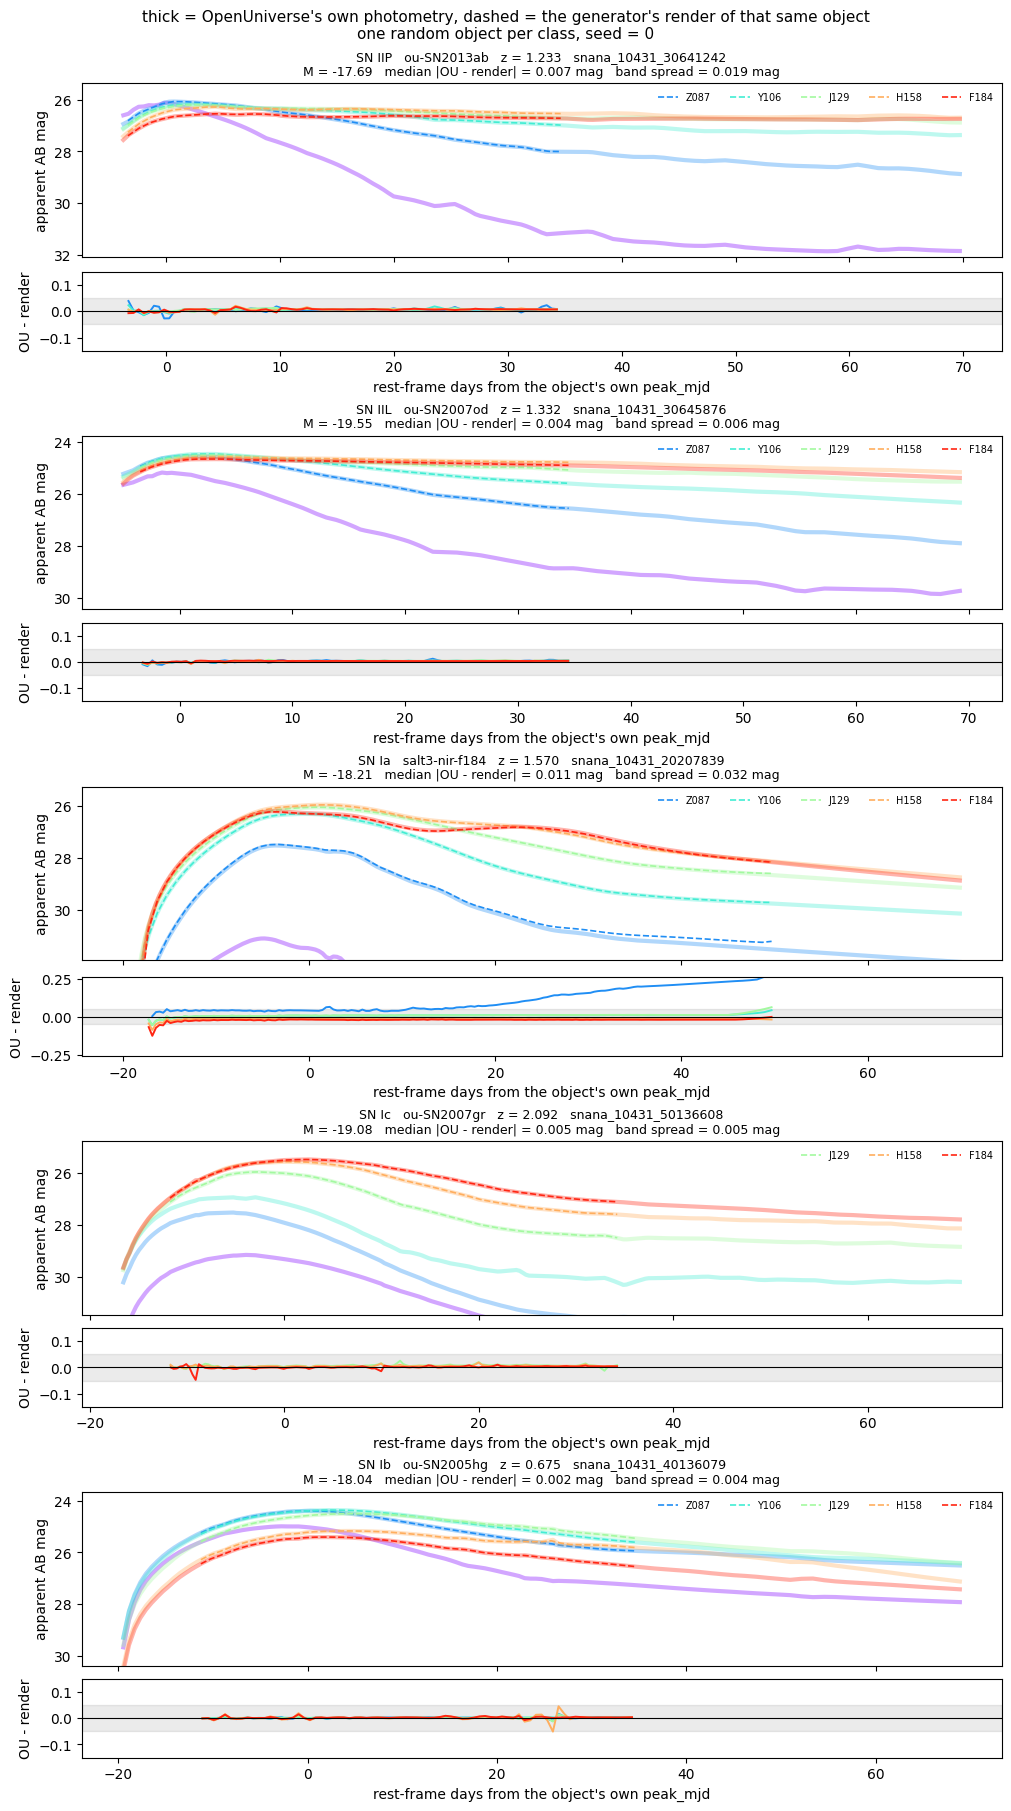

In [2]:
def show_random_parents(seed=0, plot=True):
    """A RANDOM OpenUniverse object of every class against the generator's render of it.

    This is the check the whole re-render rests on, and the one to look at first. Nothing here has
    been moved in redshift yet: each object is left where OpenUniverse put it, the generator builds
    the model the catalogue says the object was drawn from, normalises it to the brightness
    measured off THIS object's own light curve, and the two are plotted on the same axes. Every
    step of the chain -- template identification, the phase convention, the cosmology, the band
    integration -- shows up here as a disagreement if it is wrong.

    The objects are drawn at random, one per class, and nothing is hand-picked: change `seed` and
    look again. What has to be true is that the dashed render lies on the thick OpenUniverse curve
    in every band, and that the difference underneath stays inside the shaded 0.05 mag band.
    """
    _, source_by_template_index = parent_catalog()
    panels = []
    for label in CLASS_LABELS:
        drawn = sample_parents(1, label=label, seed=seed)
        if not drawn:
            print(f"no parent of {label} in the readable healpix -- skipped")
            continue
        parent = drawn[0]
        realization = measured_realization(parent)
        observed = parent_light_curve(parent)
        rendered = izc.rendered_band_curves(realization, realization["redshift"])
        panels.append((parent, realization, observed, rendered, band_residuals(observed, rendered)))

    if plot:
        figure, axes = plt.subplots(
            2 * len(panels),
            1,
            figsize=(10, 3.6 * len(panels)),
            height_ratios=[2.2, 1] * len(panels),
            constrained_layout=True,
        )
        for index, (parent, realization, observed, rendered, residuals) in enumerate(panels):
            curve_axis, residual_axis = axes[2 * index], axes[2 * index + 1]
            plot_parent_against_render(curve_axis, residual_axis, observed, rendered, residuals)
            # The two panels of one object have to be read against each other, so they cannot be
            # left on the independent x ranges their own data happen to span.
            residual_axis.sharex(curve_axis)
            curve_axis.tick_params(labelbottom=False)
            spread = np.concatenate([one[1] for one in residuals.values()]) if residuals else np.nan
            curve_axis.set_title(
                f"{realization['label']}   {realization['source_name']}   "
                f"z = {parent['redshift']:.3f}   {parent['parent_key']}\n"
                f"M = {realization['peak_absolute_magnitude']:.2f}   "
                f"median |OU - render| = {np.nanmedian(np.abs(spread)):.3f} mag   "
                f"band spread = {realization['brightness_residual']:.3f} mag",
                fontsize=9,
            )
            curve_axis.legend(fontsize=7, ncol=6, frameon=False)
            residual_axis.set_xlabel("rest-frame days from the object's own peak_mjd")
        figure.suptitle(
            "thick = OpenUniverse's own photometry, dashed = the generator's render of that same "
            f"object\none random object per class, seed = {seed}",
            fontsize=11,
        )
        plt.show()
    return panels


random_panels = show_random_parents(seed=0, plot=True)

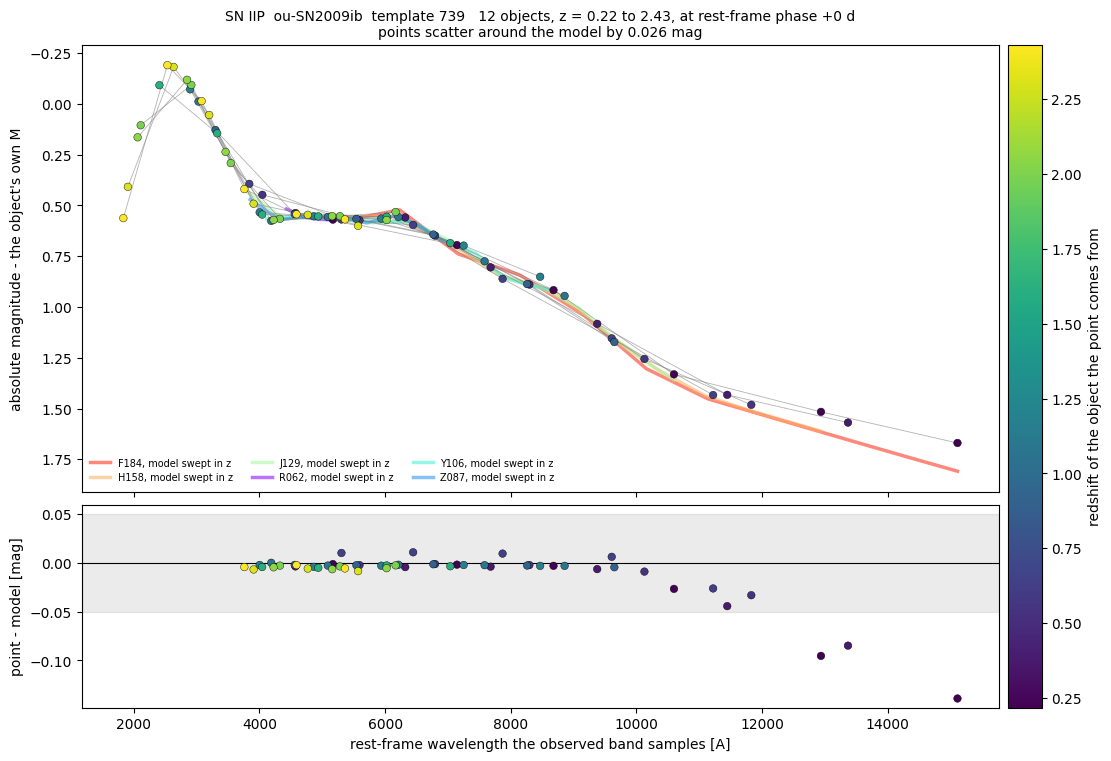

In [3]:
def show_rest_frame_sed_from_objects(label="SN IIP", count=14, phase=0.0, model_redshifts=12, seed=0, plot=True):
    """One template's rest-frame SED, traced by REAL OpenUniverse objects at many redshifts.

    THIS IS THE CELL THAT ANSWERS WHETHER THE REDSHIFTS ARE COMPARABLE, and the points in it are
    data, not model. Each object contributes one point per Roman band at the rest-frame wavelength
    that band samples for it, lambda_pivot / (1 + z), so an object at z = 0.2 fills in the near
    infrared and one at z = 2.3 fills in the ultraviolet. Objects of ONE template are one SED seen
    from different distances, so if the de-redshifting holds, points an octave apart in rest
    wavelength -- reached through different filters, from different objects, at different
    distances -- have to join into a single curve. Each object is placed vertically by its own
    measured absolute magnitude, which is the only thing that separates two objects of one
    template.

    The lines are the generator's own model of the same quantity, one per band, drawn by sweeping
    the model through redshift rather than by moving an object: they are what the sample will look
    like at the redshifts the survey has no object at. Six lines that lie on each other AND on the
    points is the statement being checked -- the same rest-frame wavelength gives the same
    magnitude whether it was reached through Z087 at z = 0.6 or through F184 at z = 1.4.

    The template is drawn at random from the ones with enough objects to trace a curve; change
    `seed` for another.
    """
    catalog, _ = parent_catalog()
    cosmology = izc.openuniverse_cosmology()
    block = catalog[catalog["resolved_label"] == label]
    populated = block["template_index"].value_counts()
    populated = populated[populated >= count]
    if not len(populated):
        raise ValueError(f"no template of {label} with at least {count} objects in the readable healpix")
    template_index = int(
        np.random.default_rng(seed).choice(populated.index.to_numpy())
    )

    points, model_realization = [], None
    for parent in sample_parents(
        count, label=label, redshift_range=(0.05, 2.6), template_index=template_index,
        spread_in_redshift=True, seed=seed,
    ):
        realization = measured_realization(parent)
        if realization["brightness_bands"] == 0:
            continue
        model_realization = realization
        redshift = float(parent["redshift"])
        observed = parent_light_curve(parent)
        for band in ROMAN_BANDS:
            if band not in observed:
                continue
            band_phase, magnitude = observed[band]
            if not (band_phase.min() <= phase <= band_phase.max()):
                continue
            apparent = float(np.interp(phase, band_phase, magnitude))
            rest_frame = apparent - cosmology.distmod(redshift).value + 2.5 * np.log10(1.0 + redshift)
            modelled = rest_frame_band_magnitude(realization, band, redshift, phase, cosmology)
            points.append(
                {
                    "parent_key": parent["parent_key"],
                    "redshift": redshift,
                    "band": band,
                    "rest_wavelength_aa": pivot_wavelength_angstrom(band) / (1.0 + redshift),
                    "relative_magnitude": rest_frame - realization["peak_absolute_magnitude"],
                    "residual": rest_frame - modelled,
                }
            )
    points = pd.DataFrame(points)

    # The model line: the same quantity, at the reference brightness, swept through redshift.
    grid = np.geomspace(points["redshift"].min(), points["redshift"].max(), model_redshifts)
    at_reference = dict(model_realization, peak_absolute_magnitude=izc.REFERENCE_ABSOLUTE_MAGNITUDE)
    model = []
    for redshift in grid:
        for band in ROMAN_BANDS:
            model.append(
                {
                    "band": band,
                    "rest_wavelength_aa": pivot_wavelength_angstrom(band) / (1.0 + redshift),
                    "relative_magnitude": rest_frame_band_magnitude(
                        at_reference, band, redshift, phase, cosmology
                    )
                    - izc.REFERENCE_ABSOLUTE_MAGNITUDE,
                }
            )
    model = pd.DataFrame(model).dropna()

    if plot:
        figure, axes = plt.subplots(
            2, 1, figsize=(11, 7.5), sharex=True, height_ratios=[2.2, 1], constrained_layout=True
        )
        for band, band_block in model.groupby("band"):
            band_block = band_block.sort_values("rest_wavelength_aa")
            axes[0].plot(
                band_block["rest_wavelength_aa"],
                band_block["relative_magnitude"],
                color=BAND_COLOUR[band],
                linewidth=2.5,
                alpha=0.55,
                label=f"{band}, model swept in z",
            )
        normalisation = plt.Normalize(*points["redshift"].agg(["min", "max"]))
        colours = plt.cm.viridis(normalisation(points["redshift"]))
        for axis, column in ((axes[0], "relative_magnitude"), (axes[1], "residual")):
            axis.scatter(
                points["rest_wavelength_aa"], points[column], c=colours,
                s=30, edgecolor="black", linewidth=0.3, zorder=3,
            )
        for _, one_object in points.groupby("parent_key"):
            one_object = one_object.sort_values("rest_wavelength_aa")
            axes[0].plot(
                one_object["rest_wavelength_aa"], one_object["relative_magnitude"],
                color="grey", linewidth=0.6, alpha=0.6, zorder=2,
            )
        axes[0].invert_yaxis()
        axes[0].set_ylabel("absolute magnitude - the object's own M")
        axes[0].set_title(
            f"{label}  {model_realization['source_name']}  template {template_index}   "
            f"{points['parent_key'].nunique()} objects, z = {points['redshift'].min():.2f} to "
            f"{points['redshift'].max():.2f}, at rest-frame phase {phase:+.0f} d\n"
            f"points scatter around the model by {points['residual'].std():.3f} mag",
            fontsize=10,
        )
        axes[0].legend(fontsize=7, ncol=3, frameon=False, loc="lower left")
        figure.colorbar(
            plt.cm.ScalarMappable(norm=normalisation, cmap="viridis"), ax=axes, pad=0.01
        ).set_label("redshift of the object the point comes from")
        axes[1].axhline(0.0, color="black", linewidth=0.8)
        axes[1].axhspan(-0.05, 0.05, color="black", alpha=0.08)
        axes[1].set_ylabel("point - model [mag]")
        axes[1].set_xlabel("rest-frame wavelength the observed band samples [A]")
        plt.show()
    return points, model


rest_frame_points, rest_frame_model = show_rest_frame_sed_from_objects(label="SN IIP", count=14, seed=0)

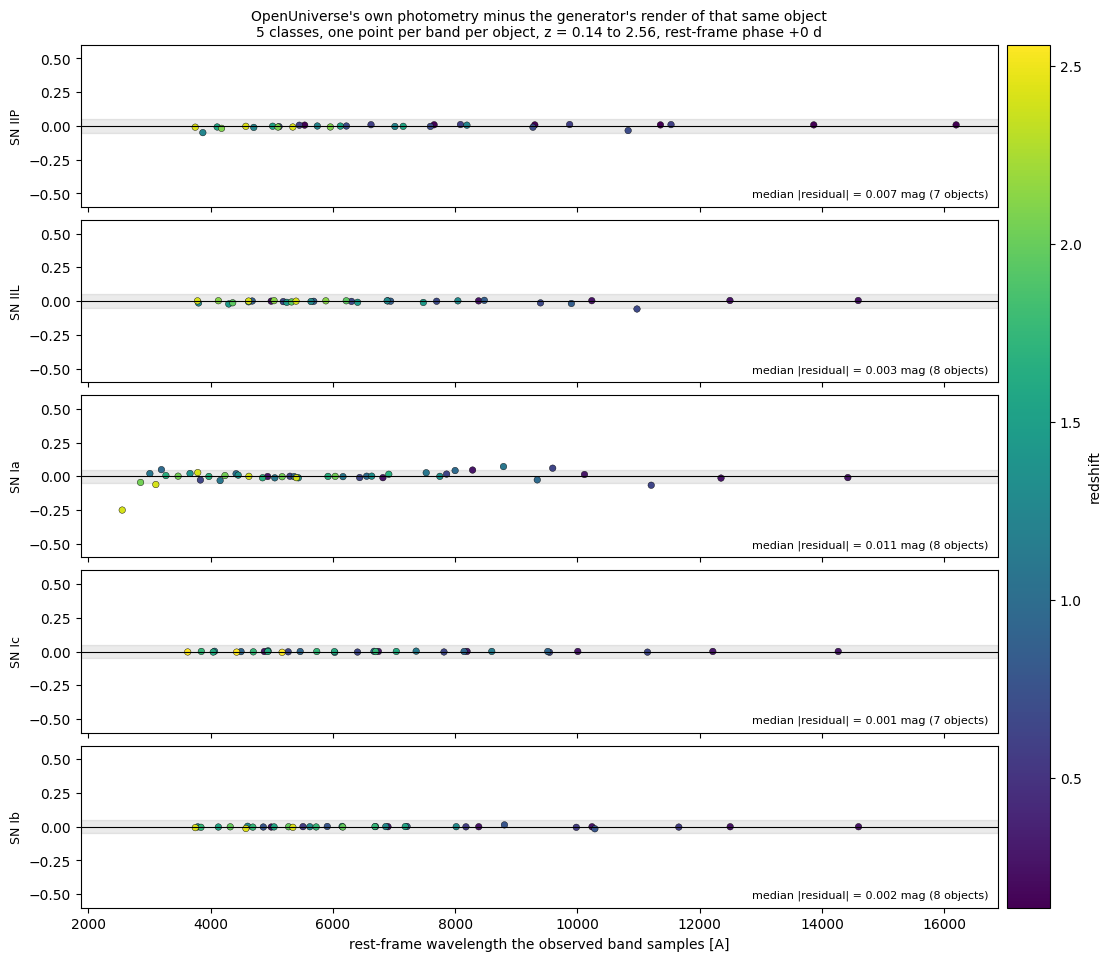

In [4]:
def show_band_residual_by_class(count=8, phase=0.0, redshift_range=(0.05, 2.6), seed=0, plot=True):
    """OpenUniverse's own photometry minus the render, band by band, over every class.

    The population version of the first cell, and the reason the random panels above are not
    cherry-picking: every class, many objects, spread across the whole redshift range the parents
    come from. Each point is one band of one object at the rest-frame wavelength that band samples
    for it, so a class whose model is OpenUniverse's own template sits on zero at every wavelength,
    and a class whose model is a declared substitution shows the substitution's colour as a trend
    across the axis. That is the sample's model uncertainty, ranked by class.

    A trend in this figure is NOT a failure of the redshift move: the same object contributes one
    point per band at one rest wavelength each, and the move is what put them there. What a broken
    de-redshifting would look like is a trend with REDSHIFT at fixed rest wavelength -- points of
    different colour separating vertically where they overlap horizontally, which is exactly what
    the colour axis is here to let you check.
    """
    cosmology = izc.openuniverse_cosmology()
    rows = []
    for label in CLASS_LABELS:
        for parent in sample_parents(
            count, label=label, redshift_range=redshift_range, spread_in_redshift=True, seed=seed
        ):
            realization = measured_realization(parent)
            if realization["brightness_bands"] == 0:
                continue
            redshift = float(parent["redshift"])
            observed = parent_light_curve(parent)
            rendered = izc.rendered_band_curves(realization, redshift, cosmology)
            for band in ROMAN_BANDS:
                if band not in observed or band not in rendered:
                    continue
                band_phase, magnitude = observed[band]
                model_phase, model_magnitude = rendered[band]
                covered = np.isfinite(model_magnitude)
                if not covered.any():
                    continue
                if not (band_phase.min() <= phase <= band_phase.max()):
                    continue
                if not (model_phase[covered].min() <= phase <= model_phase[covered].max()):
                    continue
                rows.append(
                    {
                        "label": label,
                        "band": band,
                        "redshift": redshift,
                        "rest_wavelength_aa": pivot_wavelength_angstrom(band) / (1.0 + redshift),
                        "residual": float(np.interp(phase, band_phase, magnitude))
                        - float(np.interp(phase, model_phase[covered], model_magnitude[covered])),
                    }
                )
    residuals = pd.DataFrame(rows)
    present = [one for one in CLASS_LABELS if one in set(residuals["label"])]

    if plot:
        figure, axes = plt.subplots(
            len(present), 1, figsize=(11, 1.9 * len(present)),
            sharex=True, sharey=True, constrained_layout=True,
        )
        normalisation = plt.Normalize(*residuals["redshift"].agg(["min", "max"]))
        for axis, label in zip(np.atleast_1d(axes), present):
            block = residuals[residuals["label"] == label]
            axis.axhline(0.0, color="black", linewidth=0.8)
            axis.axhspan(-0.05, 0.05, color="black", alpha=0.08)
            axis.scatter(
                block["rest_wavelength_aa"], block["residual"],
                c=plt.cm.viridis(normalisation(block["redshift"])),
                s=22, edgecolor="black", linewidth=0.3,
            )
            axis.set_ylabel(label, fontsize=9)
            axis.text(
                0.99, 0.06,
                f"median |residual| = {block['residual'].abs().median():.3f} mag "
                f"({block['redshift'].nunique()} objects)",
                transform=axis.transAxes, ha="right", fontsize=8,
            )
        np.atleast_1d(axes)[0].set_ylim(-0.6, 0.6)
        np.atleast_1d(axes)[0].set_title(
            "OpenUniverse's own photometry minus the generator's render of that same object\n"
            f"{len(present)} classes, one point per band per object, "
            f"z = {residuals['redshift'].min():.2f} to {residuals['redshift'].max():.2f}, "
            f"rest-frame phase {phase:+.0f} d",
            fontsize=10,
        )
        np.atleast_1d(axes)[-1].set_xlabel("rest-frame wavelength the observed band samples [A]")
        figure.colorbar(
            plt.cm.ScalarMappable(norm=normalisation, cmap="viridis"), ax=axes, pad=0.01
        ).set_label("redshift")
        plt.show()
    return residuals


band_residual_table = show_band_residual_by_class(count=8, seed=0)